In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/soccer-players.csv"
df = pd.read_csv(url)

In [2]:
df.columns

Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'url', 'current_club_domestic_competition_id',
       'current_club_name', 'market_value_in_eur',
       'highest_market_value_in_eur'],
      dtype='object')

In [3]:
df = df[["name", "country_of_birth", "date_of_birth", "position", "height_in_cm"]]
df.head()

,name,country_of_birth,date_of_birth,position,height_in_cm
0,Miroslav Klose,Poland,1978-06-09 00:00:00,Attack,184.0
1,Roman Weidenfeller,Germany,1980-08-06 00:00:00,Goalkeeper,190.0
2,Dimitar Berbatov,Bulgaria,1981-01-30 00:00:00,Attack,NaN
3,Lúcio,Brazil,1978-05-08 00:00:00,Defender,NaN
4,Tom Starke,East Germany (GDR),1981-03-18 00:00:00,Goalkeeper,194.0


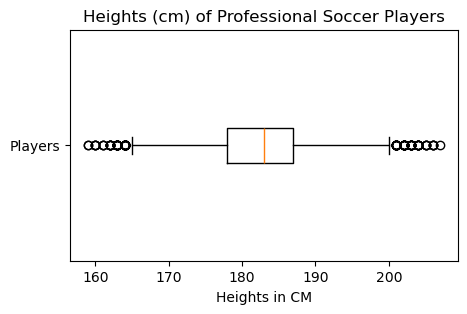

In [24]:
plt.figure(figsize=(5,3))
plt.boxplot(df.loc[df["height_in_cm"] > 150, "height_in_cm"].dropna(), vert=False)
plt.title("Heights (cm) of Professional Soccer Players")
plt.xlabel("Heights in CM")
plt.yticks(ticks=[1], labels=["Players"])
plt.show()

In [17]:
df.loc[df["height_in_cm"] > 150, "height_in_cm"].dropna()

0        184.0
1        190.0
4        194.0
7        179.0
8        193.0
         ...  
32393    186.0
32394    175.0
32398    178.0
32399    180.0
32400    164.0
Name: height_in_cm, Length: 30055, dtype: float64

In [ ]:
df.loc[df["height_in_cm"] > 185,["position", "name"]] # .loc usage: finds rows where "height_in_cm" > 185 and returns columsn position and name

,position,name
1,Goalkeeper,Roman Weidenfeller
4,Goalkeeper,Tom Starke
8,Goalkeeper,Marc Ziegler
9,Attack,Roque Santa Cruz
17,Midfield,Sebastian Kehl
...,...,...
32370,Goalkeeper,Valeriy Kosivskyi
32372,Attack,Fedir Zadorozhnyi
32374,Attack,Ahmet Mert Koşar
32380,Midfield,Yegor Tsevukh


([<matplotlib.axis.XTick at 0x19cb4a5d310>,
 [Text(1, 0, 'Attack'),
  Text(2, 0, 'Goalkeeper'),
  Text(3, 0, 'Defender'),
  Text(4, 0, 'Midfield'),
  Text(5, 0, 'Missing')])

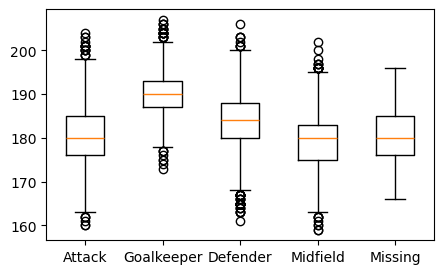

In [34]:
plt.figure(figsize=(5,3))
pos = df["position"].unique()
data = df.loc[df["height_in_cm"] > 150]
data = [data.loc[data["position"] == p, "height_in_cm"].dropna() for p in pos]
plt.boxplot(x=data, positions=range(1, len(pos)+1))

plt.xticks(ticks=range(1, len(pos)+1), labels=pos.tolist())

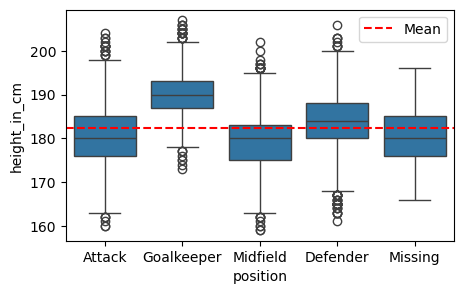

In [37]:
plt.figure(figsize=(5,3))
df = df.loc[df["height_in_cm"]>150]
ht_boxes = sns.boxplot(data=df, x="position", y="height_in_cm")
plt.axhline(y=df["height_in_cm"].mean(),color="r", linestyle="--", label="Mean")
plt.legend()
plt.show()

In [53]:
import scipy.stats as stats

def multiplot(df:pd.DataFrame, col:str, xlabel:str):
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, height_ratios=[2,8])
    box = sns.boxplot(data=df, x=col, ax=ax1,)
    hist = sns.histplot(data=df, x=col, ax=ax2, kde=True)
    sk = stats.skew(df[col], nan_policy="omit")
    kurt = stats.kurtosis(df[col], nan_policy="omit")
    box.set(xlabel="", xticks=[], yticks=[])
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    hist.set(xlabel=xlabel)
    text = f"Skew: {sk:.3f}\nKurtosis: {kurt:.3f}"
    plt.text(
        x=0.2,
        y=0.7,
        s=text,
        transform=plt.gca().transAxes,
        bbox={"boxstyle": "round, pad=0.5", "fc":"white"},
        ha="center"
    )
    plt.show()

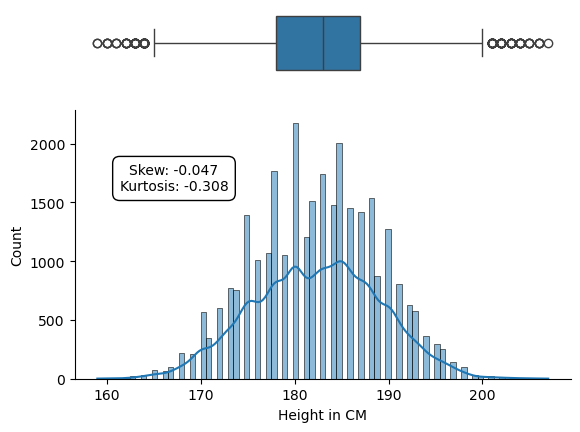

In [54]:
multiplot(df=df, col="height_in_cm", xlabel="Height in CM")

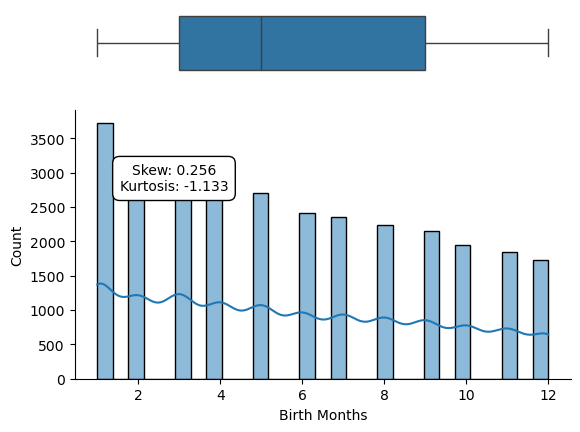

In [55]:
df["month"] = pd.to_datetime(df["date_of_birth"]).dt.month
multiplot(df=df, col="month", xlabel="Birth Months")